In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer 

In [3]:
df=pd.read_csv(r"C:\Users\SHILA\OneDrive\Desktop\PYTHON\ML_practiceDays\Datasets\titanic.csv", usecols=['Age','Fare','Survived'])
df.shape

(891, 3)

In [4]:
df.dropna(inplace=True)
df.shape

(714, 3)

In [5]:
df.sample(4)

,Survived,Age,Fare
684,0,60.0,39.0000
61,1,38.0,80.0000
730,1,29.0,211.3375
805,0,31.0,7.7750


In [6]:
x=df.iloc[ : , 1 : ]
y=df.iloc[ : , 0]

In [7]:
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
xtrain.head(4)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750


In [9]:
clf=DecisionTreeClassifier()
clf.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
ypred=clf.predict(xtest)
accuracy_score(ytest, ypred)

0.6153846153846154

In [11]:
np.mean(cross_val_score(DecisionTreeClassifier(), x, y, cv=10, scoring='accuracy'))

np.float64(0.6302621283255085)

In [12]:
kbin_age=KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile') 

In [13]:
trf=ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [14]:
xtrain_trans=trf.fit_transform(xtrain)
xtest_trans=trf.transform(xtest)

c:\Users\SHILA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\SHILA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [15]:
trf.named_transformers_['first'].n_bins_

array([15])

In [16]:
trf.named_transformers_['second'].n_bins_

array([15])

In [17]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [18]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [19]:
output=pd.DataFrame({
    'age' : xtrain['Age'],
    'age_trf' : xtrain_trans[ : , 0],
    'fare' : xtrain['Fare'],
    'fare_trf' : xtrain_trans[ : , 1] 
})

In [20]:
output['age_label']=pd.cut(x=xtrain['Age'], bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_label']=pd.cut(x=xtrain['Fare'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [21]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_label,fare_label
456,65.0,14.0,26.550,10.0,"(54.0, 80.0]","(26.0, 26.55]"
38,18.0,2.0,18.000,7.0,"(16.0, 19.0]","(14.454, 18.75]"
617,26.0,6.0,16.100,7.0,"(25.0, 28.0]","(14.454, 18.75]"
81,29.0,7.0,9.500,4.0,"(28.0, 30.0]","(8.158, 10.5]"
16,2.0,0.0,29.125,10.0,"(0.42, 6.0]","(26.55, 31.275]"


In [22]:
clf=DecisionTreeClassifier()
clf.fit(xtrain_trans,ytrain)
ypred2=clf.predict(xtest_trans)

In [23]:
accuracy_score(ytest,ypred2)

0.6363636363636364

In [24]:
xtrf=trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(), x, y, cv=10, scoring='accuracy'))

c:\Users\SHILA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\SHILA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6303012519561815)

In [25]:
# function 
def discretizer(bins,strategy):
    kbin_age=KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf=ColumnTransformer([
        ('fst', kbin_age, [0]),
        ('scnd', kbin_fare, [1])
    ])

    xtrf=trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x['Age'])
    plt.title("After")

    plt.show()

c:\Users\SHILA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\SHILA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6331181533646322


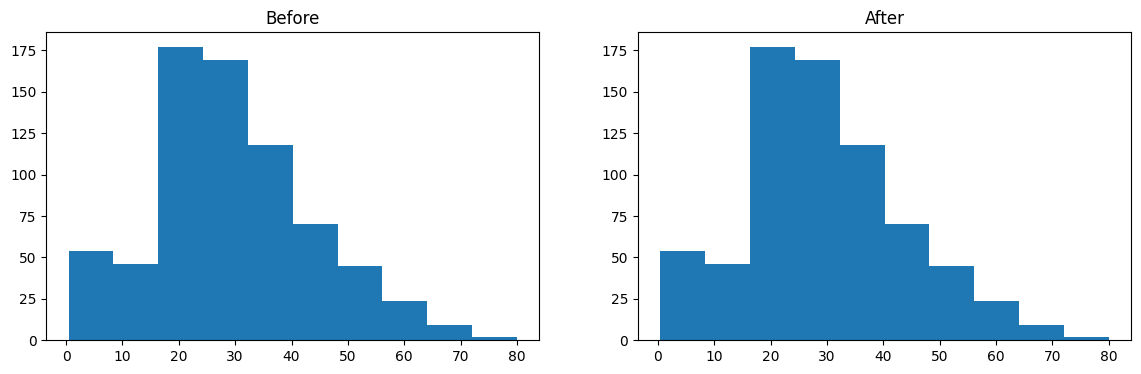

In [26]:
discretizer(10,'quantile')

0.6330985915492957


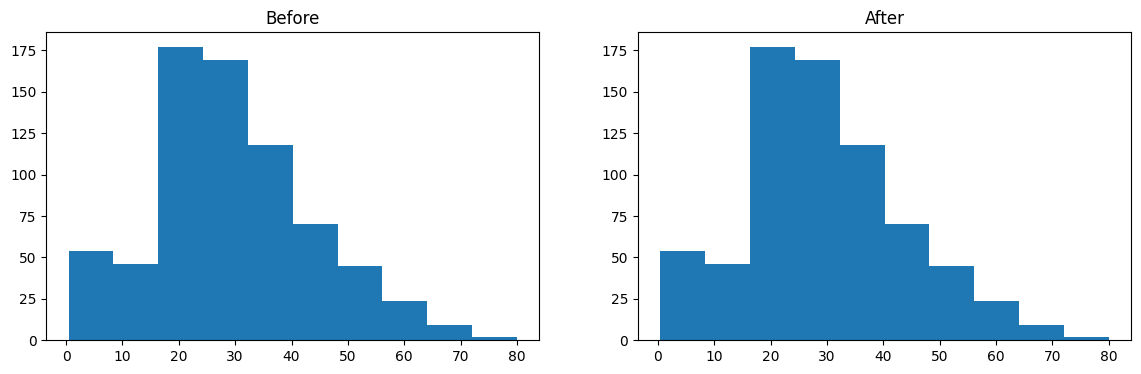

In [27]:
discretizer(10,'uniform')

0.6303403755868544


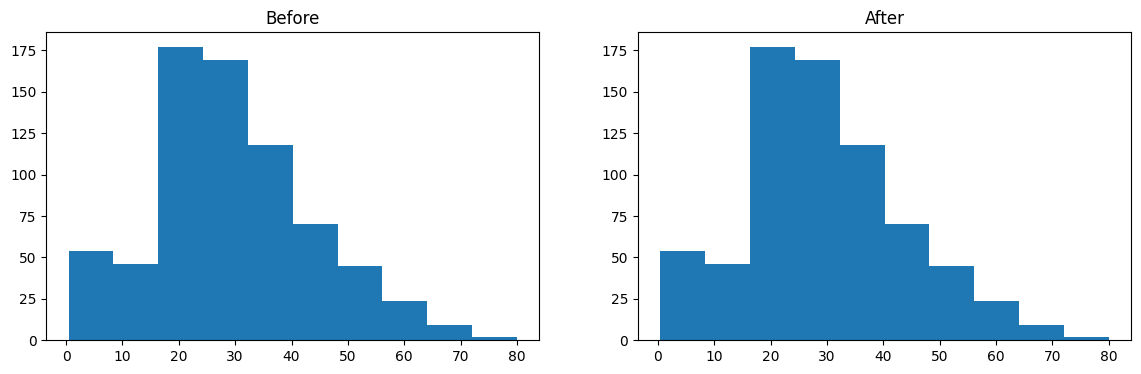

In [28]:
discretizer(5,'kmeans')